# Documentación Técnica: Clase `Fiber` (Acople a Fibra Óptica)

Este notebook describe la estructura y uso de la clase `Fiber`, una refactorización bajo el paradigma de Programación Orientada a Objetos (POO) del sistema de cálculo óptico para el acoplamiento de luz láser en fibras ópticas. Al encapsular el estado (longitud de onda, longitud focal y el MFD) dentro de un objeto, se simplifica el paso de argumentos repetitivos en los métodos de simulación.

## Arquitectura de la Clase

La clase centraliza las propiedades físicas de la fibra y de la lente utilizada en el acople, exponiendo métodos dedicados a la estimación modal y dimensional del haz de luz.

```text
+------------------------------------------------------------+
|                           Fiber                            |
+------------------------------------------------------------+
| - wavelength: float                                        |
| - focal_length: float                                      |
| - MFD: float                                               |
+------------------------------------------------------------+
| + __init__(wavelength, focal_length, MFD)                  |
| + diameter_focal_spot() -> float                           |
| + focal_length_for_diameter_focal_spot(beam_diam) -> float |
| + fiber_coupling_efficiency(omega_input) -> float          |
| + print_parameters()                                       |
| + summary()                                                |
+------------------------------------------------------------+
```

---

## Detalles del Constructor y Atributos

 `__init__(self, wavelength, focal_length, MFD)`
Inicializa una nueva instancia que representa un sistema fibra-lente específico.

**Parámetros de entrada:**

<div align="center">

| Parámetro | Tipo | Descripción |
| :--- | :--- | :--- |
| `wavelength` | `float` | Longitud de onda de la fuente de luz láser (expresada en metros). |
| `focal_length` | `float` | Longitud focal de la lente que realiza el acople (expresada en metros). |
| `MFD` | `float` | Diámetro del Campo Modal (Mode Field Diameter) de la fibra óptica (expresada en metros). |

</div>

---

## Métodos de Cálculo Físico y Óptico

1. `diameter_focal_spot(self)`
Calcula el diámetro del punto focal cuando la fibra misma actúa como la fuente (propagación inversa o estimación idealizada).

**Retorna:**
- `float`: Diámetro del punto focal en metros.

**Fórmula interna:**
$$ \frac{4 \cdot \lambda \cdot f}{\pi \cdot MFD} $$

2. `focal_length_for_diameter_focal_spot(self, diameter_input_beam)`
Determina la longitud focal requerida para una lente si se desea que un haz colimado de entrada de diámetro $D$ se reduzca exactamente al tamaño del MFD de la fibra.

**Parámetros:**

<div align="center">

| Parámetro | Tipo | Descripción |
| :--- | :--- | :--- |
| `diameter_input_beam` | `float` | Diámetro del haz colimado de entrada en metros. |

</div>

**Retorna:**
- `float`: Longitud focal requerida en metros.

3. `fiber_coupling_efficiency(self, omega_input_beam)`
Calcula la eficiencia teórica de acople ($\eta$) usando la superposición del haz enfocado por la lente y el modo propio de la fibra (aproximación gaussiana).

**Parámetros:**

<div align="center">

| Parámetro | Tipo | Descripción |
| :--- | :--- | :--- |
| `omega_input_beam` | `float` | Radio del haz colimado de entrada en metros (es decir, diámetro / 2). |

</div>

**Retorna:**
- `float`: Eficiencia como un valor decimal entre **0.0** y **1.0**.

**Fórmula interna:**
$$\eta = \left( \frac{2\omega_1\omega_2}{\omega_1^2 + \omega_2^2} \right)^2$$

Donde $\omega_1$ es el radio del haz enfocado y $\omega_2$ es el radio del modo de la fibra ($MFD / 2$).

---

## Métodos de Salida y Utilidades

4. `print_parameters(self)`
Imprime una tabla formateada en la consola con las propiedades iniciales del objeto, convirtiendo automáticamente las unidades del SI a unidades estándar de laboratorio óptico (nm, mm, y µm) para mejorar la lectura.

5. `summary(self)`
Método de abstracción que actualmente invoca a `print_parameters()`. Sirve como un punto de extensión si en el futuro se desean agregar resúmenes de cálculos automáticos al inicializar el análisis.

---
# Ejemplo 1

`# Lente de acople F110APC-633: 633 nm, f = 6.17 mm, NA = 0.38 FC/APC Collimation Pkg.
    # fibra P3-460B-FC-2: (488 - 633) nm, MFD = (2.8 - 4.1) µm @ 488 nm,`

Se tienen las siguientes condiciones físicas:
- Fuente: Láser rojo ($\lambda = 633\text{ nm}$).
- Lente inicial: Conjunto de colimación/acople con distancia focal $f = 6.17\text{ mm}$.
- Fibra de destino: MFD de $4.1\text{ }\mu\text{m}$.

In [26]:
from fiber import Fiber
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# ---- Parámetros iniciales de la luz usada y de la fibra óptica ---------------------
wavelength = 633e-9 # [m] 633 nm
focal_length = 6.17e-3 # [m] 6.17 mm
MFD = 4.1e-6 # [m] 4.1 um (MFD de la fibra óptica)

1. **Instanciación:** Se crea el objeto bajo ``fiber = Fiber(wavelength, focal_length, MFD)``.

In [28]:
fiber_red = Fiber(wavelength, focal_length, MFD)
fiber_red.summary()

--- Parámetros de entrada ---
Longitud de onda (λ):                   633 nm
Longitud focal lente de entrada (f):    6.17 mm
MFD de la fibra:                        4.1 µm
--------------------------------------------------




2. **Cálculo Inverso**: Se obtiene el diámetro teórico del haz de entrada que, al ser enfocado por la lente de $6.17\text{ mm}$, llenaría perfectamente el MFD.

In [29]:
# Diametro del haz de entrada ideal ---------------------
diameter_focal_spot = fiber_red.diameter_focal_spot() * 1e3 # Convertir a micrómetros
print(f"Diámetro del haz de entrada ideal: {diameter_focal_spot:.5f} mm")

Diámetro del haz de entrada ideal: 1.21287 mm


4. **Dimensionamiento de Lentes de Salida:** Evalúa qué longitud focal se requeriría para colimar un haz de salida expandido hasta $5.0\text{ cm}$ o $2.5\text{ mm}$.

In [30]:
# Longitud focal dle lente necesaria para haz de salida colimado---------------------
desire_output_beam_diameter = 0.05 # [m] 5.0 cm
focal_length = fiber_red.focal_length_for_diameter_focal_spot(desire_output_beam_diameter) * 1e3 # Convertir a mm
print(f"Longitud focal de lente colimador de salida: {focal_length:.2f} mm")

Longitud focal de lente colimador de salida: 254.35 mm


4. **Simulación de Pérdidas por Desacople Modal:** Se calcula la eficiencia para un haz de entrada con un diámetro pequeño de $2\text{ mm}$. La discrepancia de tamaño entre la cintura del haz enfocado y el MFD se traduce directamente en un porcentaje de eficiencia de acople bajo,

In [31]:
# Eficiencia de acople de fibra óptica. ---------------------
diameter_input_beam = 0.002# [m] 20 mm
efficiency = fiber_red.fiber_coupling_efficiency(diameter_input_beam/2)
print(f"Eficiencia de acople de fibra óptica: {efficiency:.2%}, para un diámetro de haz de entrada de {diameter_input_beam*1e3:.2f} mm")

Eficiencia de acople de fibra óptica: 78.63%, para un diámetro de haz de entrada de 2.00 mm


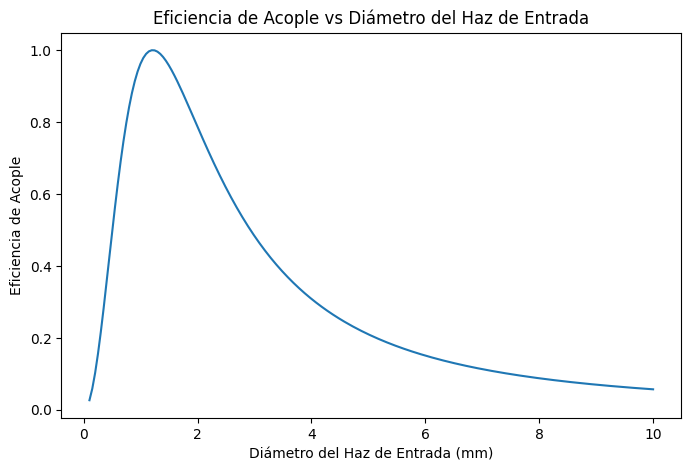

In [32]:
diameters_input_beam_red = np.linspace(0.0001, 0.010, 200)
efficiencies = [fiber_red.fiber_coupling_efficiency(d/2) for d in diameters_input_beam_red]

plt.figure(figsize=(8, 5))
plt.plot(diameters_input_beam_red*1e3, efficiencies,)
plt.title('Eficiencia de Acople vs Diámetro del Haz de Entrada')
plt.xlabel('Diámetro del Haz de Entrada (mm)')
plt.ylabel('Eficiencia de Acople')
# plt.grid()
plt.show()

---
# Ejemplo 2

`# Lente de acople F110APC-633: 633 nm, f = 6.17 mm, NA = 0.38 FC/APC Collimation Pkg.
    # fibra P3-460B-FC-2: (488 - 633) nm, MFD = (2.8 - 4.1) µm @ 488 nm,`

Se tienen las siguientes condiciones físicas:
- Fuente: Láser verde de Helio-Neón ($\lambda = 543.365\text{ nm}$).
- Lente inicial: Conjunto de colimación/acople con distancia focal $f = 6.17\text{ mm}$.
- Fibra de destino: MFD de $4.1\text{ }\mu\text{m}$.

In [35]:
# ---- Parámetros iniciales de la luz usada y de la fibra óptica ---------------------
wavelength_green = 543.5e-9 # [m] 543.5 nm
focal_length = 6.17e-3 # [m] 6.17 mm
MFD = 3.3e-6 # [m] 3.3 um (MFD de la fibra óptica)

fiber_green = Fiber(wavelength_green, focal_length, MFD)
fiber_green.summary()

# Diametro del haz de entrada ideal ---------------------
diameter_focal_spot = fiber_green.diameter_focal_spot() * 1e3 # Convertir a milimetros
print(f"Diámetro del haz de entrada ideal: {diameter_focal_spot:.5f} mm")

# Eficiencia de acople de fibra óptica. ---------------------
diameter_input_beam = 0.00086 # [m] 0.86  mm
efficiency = fiber_green.fiber_coupling_efficiency(diameter_input_beam/2)
print(f"Eficiencia de acople de fibra óptica: {efficiency:.2%}, para un diámetro de haz de entrada de {diameter_input_beam*1e3:.2f} mm")

--- Parámetros de entrada ---
Longitud de onda (λ):                   544 nm
Longitud focal lente de entrada (f):    6.17 mm
MFD de la fibra:                        3.3 µm
--------------------------------------------------


Diámetro del haz de entrada ideal: 1.29384 mm
Eficiencia de acople de fibra óptica: 85.01%, para un diámetro de haz de entrada de 0.86 mm


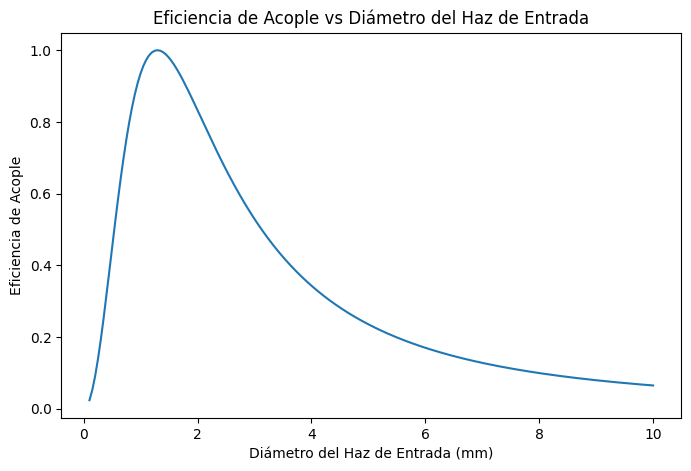

In [34]:
diameters_input_beam = np.linspace(0.0001, 0.010, 200)
efficiencies = [fiber_green.fiber_coupling_efficiency(d/2) for d in diameters_input_beam]

plt.figure(figsize=(8, 5))
plt.plot(diameters_input_beam*1e3, efficiencies,)
plt.title('Eficiencia de Acople vs Diámetro del Haz de Entrada')
plt.xlabel('Diámetro del Haz de Entrada (mm)')
plt.ylabel('Eficiencia de Acople')
# plt.grid()
plt.show()